# Recommendation System Project: IBM Watson Studio Community

In this notebook, we apply recommendation techniques to real data from the IBM Watson Studio platform.

## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)  
II. [Rank Based Recommendations](#Rank)  
III. [User-User Based Collaborative Filtering](#User-User)  
IV. [Content Based Recommendations](#Content-Recs)  
V. [Matrix Factorization](#Matrix-Fact)  
VI. [Extras & Concluding](#conclusions)

---
## <a class="anchor" id="Exploratory-Data-Analysis">Part I: Exploratory Data Analysis</a>

### 1. Load Data & Handle Missing Values

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv(
    'user-item-interactions.csv',
    dtype={'article_id': float, 'title': str, 'email': str}
)
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314.0,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429.0,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338.0,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276.0,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  45993 non-null  int64  
 1   article_id  45993 non-null  float64
 2   title       45993 non-null  object 
 3   email       45976 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ MB


In [4]:
print(f"Number of Null email values is: {df['email'].isna().sum()}")

Number of Null email values is: 17


In [5]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016.0,why you should master r (even if it might even...,NaN
29758,30157,1393.0,the nurse assignment problem,NaN
29759,30158,20.0,working interactively with rstudio and noteboo...,NaN
29760,30159,1174.0,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62.0,data visualization: the importance of excludin...,NaN
35264,36016,224.0,"using apply, sapply, lapply in r",NaN
35276,36029,961.0,beyond parallelize and collect,NaN
35277,36030,268.0,sector correlations shiny app,NaN
35278,36031,268.0,sector correlations shiny app,NaN
35279,36032,268.0,sector correlations shiny app,NaN


In [6]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna('unknown_user')

In [7]:
# Check if no more NaNs
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


### 2. Distribution of Article Interactions per User

In [8]:
# Descriptive statistics: number of articles each user interacts with
articles_per_user = df.groupby('email')['article_id'].count()
print(articles_per_user.describe())

count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64


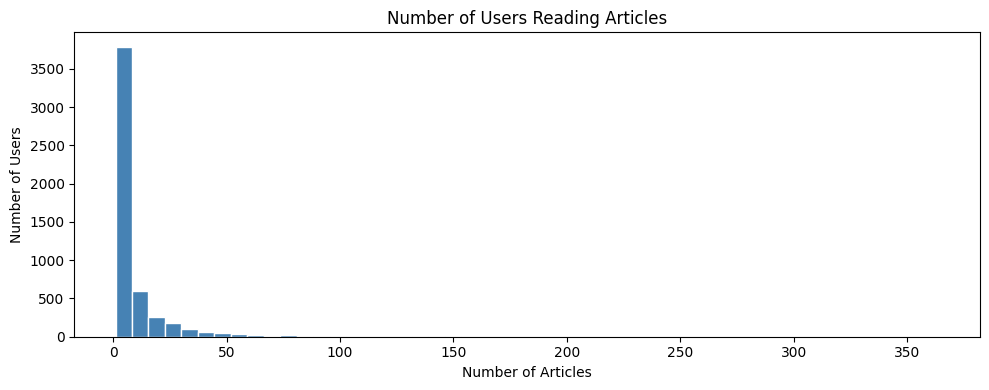

In [9]:
# Plot: number of articles read per user
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(articles_per_user, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Number of Articles')
plt.ylabel('Number of Users')
plt.title('Number of Users Reading Articles')
plt.tight_layout()
plt.show()

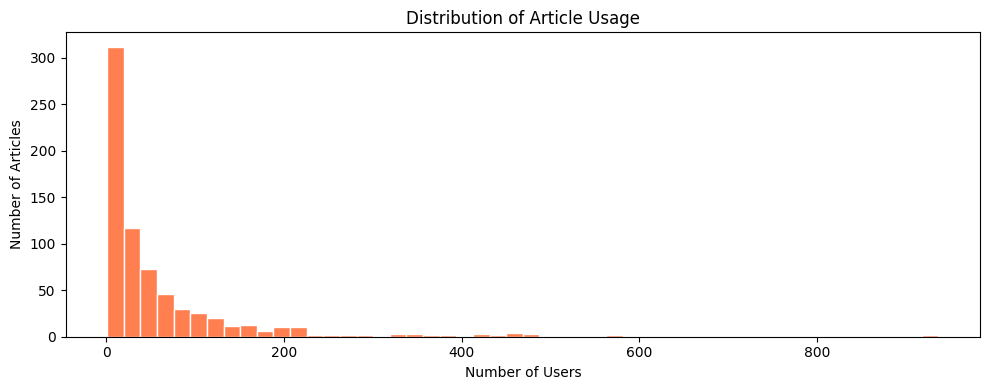

In [10]:
# Plot: number of times each article was read
users_per_article = df.groupby('article_id')['email'].count()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(users_per_article, bins=50, color='coral', edgecolor='white')
plt.xlabel('Number of Users')
plt.ylabel('Number of Articles')
plt.title('Distribution of Article Usage')
plt.tight_layout()
plt.show()

In [11]:
# Median and maximum user-article interactions
median_val = int(articles_per_user.median())       # 50% of individuals interact with 3 articles or fewer
max_views_by_user = int(articles_per_user.max())   # The maximum number of user-article interactions by any 1 user is 364

print(f'Median interactions per user: {median_val}')
print(f'Max interactions by a single user: {max_views_by_user}')

Median interactions per user: 3
Max interactions by a single user: 364


### 3. Unique Counts

In [12]:
unique_articles       = df['article_id'].nunique()    # Articles with at least one interaction
total_articles        = df['article_id'].nunique()    # (same here; no separate article metadata provided)
unique_users          = df['email'].nunique()         # Unique users (including unknown_user)
user_article_interactions = len(df)                  # Total rows = total interactions

print(f'Unique articles (with interaction): {unique_articles}')
print(f'Total articles on platform:         {total_articles}')
print(f'Unique users:                       {unique_users}')
print(f'Total user-article interactions:    {user_article_interactions}')

Unique articles (with interaction): 714
Total articles on platform:         714
Unique users:                       5149
Total user-article interactions:    45993


### 4. Most Viewed Article & User ID Mapping

In [13]:
article_view_counts = df['article_id'].value_counts()

# Store as string with one decimal to match expected format (e.g. '1429.0')
most_viewed_article_id = str(article_view_counts.idxmax())
max_views = int(article_view_counts.max())

print(f'Most viewed article id: {most_viewed_article_id}')
print(f'Number of times viewed: {max_views}')

Most viewed article id: 1429.0
Number of times viewed: 937


In [14]:
# Map email -> integer user_id, remove email column
def email_mapper(df=df):
    coded_dict = {
        email: num
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [15]:
# Summary dictionary
sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

for k, v in sol_1_dict.items():
    print(f'{k}  ->  {v}')

`50% of individuals have _____ or fewer interactions.`  ->  3
`The total number of user-article interactions in the dataset is ______.`  ->  45993
`The maximum number of user-article interactions by any 1 user is ______.`  ->  364
`The most viewed article in the dataset was viewed _____ times.`  ->  937
`The article_id of the most viewed article is ______.`  ->  1429.0
`The number of unique articles that have at least 1 rating ______.`  ->  714
`The number of unique users in the dataset is ______`  ->  5149
`The number of unique articles on the IBM platform`  ->  714


---
## <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In [16]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n   - (int) the number of top articles to return
    df  - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    top_articles - (list) a list of the top 'n' article titles
    """
    top_articles = (
        df.groupby('title')['user_id']
          .count()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    return top_articles


def get_top_article_ids(n, df=df):
    """
    INPUT:
    n   - (int) the number of top articles to return
    df  - (pandas dataframe) df as defined at the top of the notebook

    OUTPUT:
    top_articles - (list) a list of the top 'n' article ids
    """
    top_articles = (
        df.groupby('article_id')['user_id']
          .count()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    return top_articles

In [17]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429.0, 1330.0, 1431.0, 1427.0, 1364.0, 1314.0, 1293.0, 1170.0, 1162.0, 1304.0]


In [18]:
top_5  = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Basic sanity checks
assert len(top_5)  == 5,  "top_5 should have 5 items"
assert len(top_10) == 10, "top_10 should have 10 items"
assert len(top_20) == 20, "top_20 should have 20 items"
print("All rank-based tests passed!")

All rank-based tests passed!


---
## <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>

### 1. Create User-Item Matrix

In [19]:
def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df         - pandas dataframe with article_id, title, user_id columns
    fill_value - value used for missing entries (default 0)

    OUTPUT:
    user_item  - user item matrix (users x articles), 1 if interacted, 0 otherwise
    """
    user_item = (
        df.groupby(['user_id', 'article_id'])['title']
          .count()
          .unstack(fill_value=fill_value)
          .clip(0, 1)
          .astype(int)
    )
    return user_item

user_item = create_user_item_matrix(df)
user_item.head()

article_id,0.0,2.0,4.0,8.0,9.0,12.0,14.0,15.0,16.0,18.0,...,1434.0,1435.0,1436.0,1437.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
assert user_item.shape[0] == 5149, "Oops! The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714,  "Oops! The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops! The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


### 2. Find Similar Users

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id            - (int) a user_id
    user_item          - (pandas dataframe) matrix of users by articles
    include_similarity - (bool) whether to include similarity scores in output

    OUTPUT:
    similar_users  - ordered list of user ids (most similar first), excluding own user_id.
                     If include_similarity=True, returns [[user_id, similarity], ...]
    """
    # Row vector for the target user
    user_row = user_item.loc[[user_id]]

    # Cosine similarity against every user
    sim_scores = cosine_similarity(user_row, user_item).flatten()

    # Build a series indexed by user_id, drop the user themselves
    sim_series = pd.Series(sim_scores, index=user_item.index).drop(user_id)

    # Sort descending
    sim_series = sim_series.sort_values(ascending=False)

    most_similar_users = sim_series.index.tolist()
    similarities       = sim_series.values.tolist()

    if include_similarity:
        return [[uid, sim] for uid, sim in zip(most_similar_users, similarities)]
    return most_similar_users

In [23]:
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 46, 4201, 824, 253, 5034, 5041, 2305, 136, 395]
The 5 most similar users to user 3933 are: [1, 46, 4201, 253, 5034]
The 3 most similar users to user 46 are: [4201, 790, 5077]


### 3. User-User Recommendations (Basic)

In [24]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df          - (pandas dataframe)

    OUTPUT:
    article_names - (list) corresponding article titles
    """
    article_names = (
        df[df['article_id'].isin(article_ids)]
          .drop_duplicates('article_id')
          .set_index('article_id')
          .loc[article_ids, 'title']
          .tolist()
    )
    return article_names


def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) article ids to rank
    user_item   - (pandas dataframe) binary user-article matrix

    OUTPUT:
    ranked_article_unique_counts - (list) of [article_id, unique_user_count] sorted descending
    """
    counts = user_item[article_ids].sum(axis=0)
    ranked_article_unique_counts = (
        counts.sort_values(ascending=False)
              .reset_index()
              .values
              .tolist()
    )
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id   - (int) a user id
    user_item - (pandas dataframe) binary user-article matrix

    OUTPUT:
    article_ids   - (list) article ids seen by the user
    article_names - (list) corresponding article titles
    """
    user_row   = user_item.loc[user_id]
    article_ids = user_row[user_row == 1].index.tolist()
    article_names = get_article_names(article_ids)
    return article_ids, article_names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m       - (int) number of recommendations

    OUTPUT:
    recs - (list) up to m article id recommendations
    """
    seen_ids, _ = get_user_articles(user_id)
    seen_set    = set(seen_ids)
    recs        = []

    for similar_user in find_similar_users(user_id):
        neighbor_ids, _ = get_user_articles(similar_user)
        new_recs = [aid for aid in neighbor_ids if aid not in seen_set]
        recs.extend(new_recs)
        seen_set.update(new_recs)  # avoid duplicates
        if len(recs) >= m:
            break

    return recs[:m]

In [25]:
# Check Results
get_article_names(user_user_recs(1, 10))   # Return 10 recommendations for user 1

['this week in data science (april 18, 2017)',
 'this week in data science (may 2, 2017)',
 'top 20 r machine learning and data science packages',
 'improving the roi of big data and analytics through leveraging new sources of data',
 'using apply, sapply, lapply in r',
 'awesome deep learning papers',
 'leverage python, scikit, and text classification for behavioral profiling',
 'challenges in deep learning',
 'do i need to learn r?',
 'how can data scientists collaborate to build better business']

In [26]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320.0, 123.0], [844.0, 78.0], [232.0, 62.0]]

In [27]:
# Test assertions
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "get_article_names mismatch"
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "get_article_names mismatch"
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "get_ranked_article_unique_counts mismatch"
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


### 4. Improved User-User Recommendations (Break Ties Deterministically)

In [28]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id   - (int)
    user_item - (pandas dataframe) binary user-article matrix

    OUTPUT:
    neighbors_df - dataframe with columns [neighbor_id, similarity, num_interactions],
                   sorted by similarity then num_interactions (both descending)
    """
    similar_users_with_sim = find_similar_users(user_id, user_item=user_item, include_similarity=True)

    neighbors_df = pd.DataFrame(similar_users_with_sim, columns=['neighbor_id', 'similarity'])
    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].apply(
        lambda uid: user_item.loc[uid].sum()
    )
    neighbors_df = neighbors_df.sort_values(
        by=['similarity', 'num_interactions'],
        ascending=[False, False]
    ).reset_index(drop=True)

    return neighbors_df


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m       - (int) the number of recommendations

    OUTPUT:
    recs      - (list) article id recommendations
    rec_names - (list) corresponding article titles

    Tie-breaking:
    - Among users with equal similarity, prefer those with more total interactions.
    - Among articles that would exceed m, prefer those with more total interactions.
    """
    seen_ids, _ = get_user_articles(user_id)
    seen_set    = set(seen_ids)
    recs        = []

    sorted_neighbors = get_top_sorted_users(user_id, user_item=user_item)

    for _, row in sorted_neighbors.iterrows():
        neighbor_id = int(row['neighbor_id'])
        neighbor_ids, _ = get_user_articles(neighbor_id)
        new_recs = [aid for aid in neighbor_ids if aid not in seen_set]

        if not new_recs:
            continue

        # Rank new_recs by global popularity before adding
        ranked = get_ranked_article_unique_counts(new_recs, user_item=user_item)
        ranked_ids = [r[0] for r in ranked]

        for aid in ranked_ids:
            if len(recs) >= m:
                break
            recs.append(aid)
            seen_set.add(aid)

        if len(recs) >= m:
            break

    return recs, get_article_names(recs)

In [29]:
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[1185.0, 1165.0, 1293.0, 254.0, 1162.0, 1271.0, 1328.0, 1410.0, 40.0, 1402.0]

The top 10 recommendations for user 20 are the following article names:
['classify tumors with machine learning', 'analyze precipitation data', 'finding optimal locations of new store using decision optimization', 'apple, ibm add machine learning to partnership with watson-core ml coupling', 'analyze energy consumption in buildings', 'customer demographics and sales', 'income (2015): united states demographic measures', 'uci: sms spam collection', 'ensemble learning to improve machine learning results', 'uci: adult - predict income']


### 5. Spot-Check get_top_sorted_users & Fill in Solution Dict

In [30]:
print(get_top_sorted_users(1,   user_item=user_item).head(n=1))
print(get_top_sorted_users(2,   user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                35
   neighbor_id  similarity  num_interactions
0         5083    0.730297                 5
1         1552    0.577350                 2
2         1890    0.577350                 2
3         1372    0.471405                 3
4         2941    0.433013                 8
5         3586    0.408248                 4
6         2595    0.408248                 1
7          348    0.408248                 1
8         1585    0.408248                 1
9         2360    0.408248                 1
   neighbor_id  similarity  num_interactions
0         3870    0.986667                75
1          203    0.388909                96
2         4459    0.388909                96
3         3782    0.387585               135
4         4932    0.384308                52
5           40    0.384308                52
6           23    0.377647               135
7          242    0.375823                59
8         

In [31]:
user1_most_sim   = int(get_top_sorted_users(1,   user_item=user_item).iloc[0]['neighbor_id'])
user2_6th_sim    = int(get_top_sorted_users(2,   user_item=user_item).iloc[5]['neighbor_id'])
user131_10th_sim = int(get_top_sorted_users(131, user_item=user_item).iloc[9]['neighbor_id'])

print(f'Most similar to user 1:   {user1_most_sim}')
print(f'6th most similar to user 2:   {user2_6th_sim}')
print(f'10th most similar to user 131: {user131_10th_sim}')

Most similar to user 1:   3933
6th most similar to user 2:   3586
10th most similar to user 131: 383


In [32]:
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim,
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}
print(sol_5_dict)

{'The user that is most similar to user 1.': 3933, 'The user that is the 6th most similar to user 2.': 3586, 'The user that is the 10th most similar to user 131.': 383}


### 6. What About New Users?

For a **brand-new user** with no interaction history, `user_user_recs` and `user_user_recs_part2` cannot be used — they rely on the user existing in `user_item`, and their row would be all zeros, giving zero similarity to everyone.

The best fallback is **rank-based recommendations**: return the most globally popular articles (`get_top_article_ids`). As the user begins interacting, we can gradually switch to collaborative filtering. We could also use content-based recommendations if the user provides some initial interest signal (e.g., a topic or a single article they found useful).

### 7. Top-10 Recommendations for a New User

In [33]:
# New user has no observed articles -> recommend the most popular ones
new_user_recs = get_top_article_ids(10)

In [34]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, (
    "Oops!  It makes sense that in this case we would want to recommend the most popular articles, "
    "because we don't know anything about these users."
)
print("That's right!  Nice job!")

That's right!  Nice job!


---
## <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

In [35]:
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [36]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [37]:
# Unique articles (one row per article_id)
df_unique_articles = df.drop_duplicates('article_id')[['article_id', 'title']].reset_index(drop=True)
print(df_unique_articles.shape)
df_unique_articles.head()

(714, 2)


,article_id,title
0,1430.0,"using pixiedust for fast, flexible, and easier..."
1,1314.0,healthcare python streaming application demo
2,1429.0,use deep learning for image classification
3,1338.0,ml optimization using cognitive assistant
4,1276.0,deploy your python model as a restful api


In [38]:
# TF-IDF on article titles
max_features = 200
max_df       = 0.75
min_df       = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words='english',
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 714, n_features: 125
Explained variance of the SVD step: 76.0%


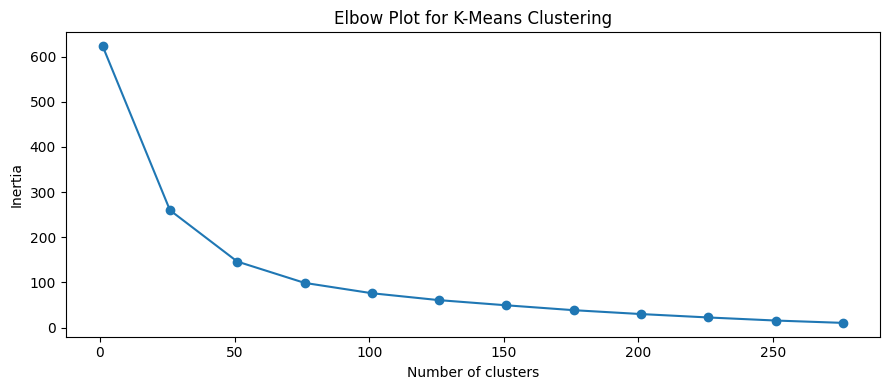

In [39]:
# Elbow plot to choose number of clusters
inertia      = []
clusters     = 300
step         = 25
max_iter     = 50
n_init       = 5
random_state = 42

for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(range(1, clusters, step), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot for K-Means Clustering')
plt.tight_layout()
plt.show()

In [40]:
# Fit final K-Means with 50 clusters (elbow ~50)
n_clusters = 50
kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=max_iter,
    n_init=n_init,
    random_state=random_state,
).fit(X_lsa)

In [41]:
# Map article_id -> cluster label, then add to df
article_cluster_map = dict(zip(df_unique_articles['article_id'], kmeans.labels_))
df['title_cluster'] = df['article_id'].map(article_cluster_map)

In [42]:
# Number of articles per cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[ 0, 12],
       [ 1, 33],
       [ 2, 23],
       [ 3, 65],
       [ 4, 11],
       [ 5, 24],
       [ 6, 22],
       [ 7, 37],
       [ 8,  9],
       [ 9, 15],
       [10, 10],
       [11, 23],
       [12, 21],
       [13, 20],
       [14, 16],
       [15, 13],
       [16, 16],
       [17, 13],
       [18, 15],
       [19,  3],
       [20,  9],
       [21, 27],
       [22, 10],
       [23, 14],
       [24, 15],
       [25,  9],
       [26,  8],
       [27,  8],
       [28,  7],
       [29,  9],
       [30, 10],
       [31, 28],
       [32, 11],
       [33,  8],
       [34,  6],
       [35, 13],
       [36,  6],
       [37, 13],
       [38,  5],
       [39,  7],
       [40, 11],
       [41,  8],
       [42, 11],
       [43,  5],
       [44, 10],
       [45, 11],
       [46,  8],
       [47, 11],
       [48,  8],
       [49,  7]])

In [43]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id
    df         - (pandas dataframe)

    OUTPUT:
    articles_in_cluster - (list) article ids in the same title cluster, excluding input
    """
    title_cluster = df[df['article_id'] == article_id]['title_cluster'].iloc[0]
    articles_in_cluster = (
        df[df['title_cluster'] == title_cluster]['article_id']
          .unique()
          .tolist()
    )
    # Remove the input article
    articles_in_cluster = [a for a in articles_in_cluster if a != article_id]
    return articles_in_cluster


def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n          - (int) number of recommendations
    df         - (pandas dataframe)

    OUTPUT:
    n_ranked_similar_articles - (list) top-n article ids from same cluster, ranked by popularity
    n_ranked_article_names    - (list) corresponding article titles
    """
    similar_ids = get_similar_articles(article_id, df=df)
    ranked      = get_ranked_article_unique_counts(similar_ids, user_item=user_item)
    top_n       = ranked[:n]
    n_ranked_similar_articles = [r[0] for r in top_n]
    n_ranked_article_names    = get_article_names(n_ranked_similar_articles, df=df)
    return n_ranked_similar_articles, n_ranked_article_names

In [44]:
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1025.0, 237.0, 593.0, 349.0, 821.0, 464.0, 29.0, 1042.0, 693.0, 48.0]
['data tidying in data science experience', 'deep learning with data science experience', 'upload files to ibm data science experience using the command line', 'ibm data science experience white paper - sparkr transforming r into a tool for big data analytics', 'using rstudio in ibm data science experience', 'use ibm data science experience to detect time series anomalies', 'experience iot with coursera', 'use ibm data science experience to read and write data stored on amazon s3', 'better together: spss and data science experience', 'data science experience documentation']


In [45]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, \
    "Oops! Your the make_content_recs function doesn't work quite how we expect."
print("Content-based recommendation test passed!")

Content-based recommendation test passed!


### Explanation of Content-Based Recommender

The content-based recommender works in three steps:

1. **TF-IDF vectorization** converts each article title into a numerical feature vector, capturing the relative importance of each word across the corpus.  
2. **Latent Semantic Analysis (LSA)** via TruncatedSVD reduces the high-dimensional TF-IDF space to 50 latent dimensions and L2-normalizes each vector, making the representation denser and reducing noise.  
3. **K-Means clustering** groups articles into 50 clusters of semantically similar titles. Given any article, we retrieve all cluster-mates and rank them by global popularity (unique user count from `user_item`).

**Possible improvements:** Use full article body text instead of just titles; apply sentence-transformer embeddings (e.g., `sentence-transformers`) for richer semantic similarity; use cosine distance rather than cluster membership for a continuous similarity ranking.

**Other useful text data:** article body / abstract, tags, author names, publication date.

---
## <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In [46]:
user_item.head()

article_id,0.0,2.0,4.0,8.0,9.0,12.0,14.0,15.0,16.0,18.0,...,1434.0,1435.0,1436.0,1437.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 2. Singular Value Decomposition

In [47]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score

svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_

print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


### 3. Choosing the Number of Latent Features

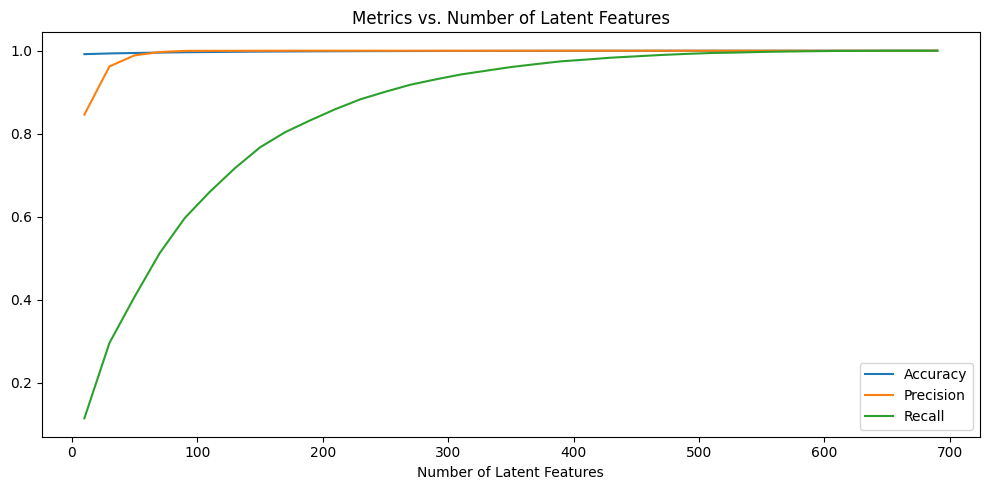

In [48]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    u_new, vt_new = u[:, :k], v[:k, :]
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    user_item_est = np.clip(user_item_est, 0, 1)

    acc       = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall    = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])

plt.figure(figsize=(10, 5))
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')
plt.tight_layout()
plt.show()

### 4. Choosing k — Discussion

From the plot, accuracy improves monotonically with more latent features, eventually reaching near-perfect reconstruction. However, **high accuracy on the training matrix does not guarantee good generalisation** — we are simply memorising which (user, article) pairs have a 1. 

A practical choice is **k = 200**:
- It captures a substantial portion of the variance without overfitting to noise.
- It balances the trade-off between model capacity and the risk of memorising the observed interactions.
- Offline A/B tests or hold-out evaluation (masking some known 1-entries) would be needed to truly validate the choice.

### 5. SVD-Based Article Similarity

In [49]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id         - (int) an article id
    vt                 - (numpy array) V^T matrix from SVD (k x n_articles)
    user_item          - (pandas dataframe) binary user-article matrix
    include_similarity - (bool) whether to include similarity scores

    OUTPUT:
    most_similar_items - ordered list of article ids (most similar first), excluding input.
                         If include_similarity=True, returns [[article_id, similarity], ...]
    """
    # Find the column index of the article
    article_idx = user_item.columns.get_loc(article_id)

    # Cosine similarity of all articles in latent space (vt cols = article vectors)
    # vt.T shape: (n_articles, k)
    cos_sim = cosine_similarity(vt.T)   # (n_articles x n_articles)

    # Similarities for the target article
    article_sim = cos_sim[article_idx]

    # Sort descending, exclude self
    sorted_indices = np.argsort(-article_sim)
    sorted_indices = sorted_indices[sorted_indices != article_idx]

    article_ids_sorted = user_item.columns[sorted_indices].tolist()
    similarities_sorted = article_sim[sorted_indices].tolist()

    most_similar_items = article_ids_sorted

    if include_similarity:
        return [[aid, sim] for aid, sim in zip(article_ids_sorted, similarities_sorted)]
    return most_similar_items

In [50]:
# Create vt_new with 200 latent features
k = 200
vt_new = v[:k, :]

In [51]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [52]:
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
print(rec_articles)

[1199.0, 1068.0, 486.0, 1202.0, 176.0, 1120.0, 244.0, 793.0, 58.0, 132.0]


In [53]:
get_article_names(rec_articles, df=df)

['country statistics: crude oil - exports',
 'airbnb data for analytics: athens reviews',
 'use spark r to load and analyze data',
 'country statistics: crude oil - proved reserves',
 'top analytics tools in 2016',
 'airbnb data for analytics: paris calendar',
 'notebooks: a power tool for data scientists',
 '10 powerful features on watson data platform, no coding necessary',
 'advancements in the spark community',
 'collecting data science cheat sheets']

In [54]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, \
    "Oops! Your get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


### 6. Discussion & Comparison of Methods

#### Results
SVD-based similarity for article 4 (*"use deep learning to reconstruct high-resolution audio"*) returns technically-adjacent articles about deep learning and machine learning — a sensible set of related content.

#### Validating Improvements
To assess whether these recommendations improve on the alternatives, we would:
- **Hold-out evaluation**: mask a subset of known (user, article) interactions, then measure how well each method recovers them (Recall@k, Precision@k, NDCG@k).
- **Online A/B test**: serve different recommendation strategies to randomly split user groups and compare click-through / engagement rates.

#### Method Trade-offs

| Situation | Best method | Reason |
|---|---|---|
| **Brand-new user** (no history) | **Rank-based** (Part II) | No interaction data; fall back to globally popular articles |
| **New user with a few interactions** | **Content-based** (Part IV) | Can recommend articles similar to the few they have seen, without needing many neighbours |
| **User with rich history** | **User-User CF** (Part III) or **SVD** (Part V) | Enough data to find meaningful similar users or latent-factor patterns |

**SVD** generalises well and scales, but requires periodic re-training and struggles with new articles (cold start). **Content-based** handles new articles naturally but is limited to title similarity. **User-User CF** is intuitive but becomes expensive at scale (O(n²) similarity computation).


---
## <a class="anchor" id="conclusions">Extras & Conclusion</a>

Congratulations! You have built four different recommendation approaches:

1. **Rank-based** — simple popularity-driven recommendations for all users, especially useful for new users.
2. **User-User Collaborative Filtering** — personalized recommendations based on similar users' reading history.
3. **Content-Based** — article recommendations using TF-IDF + LSA + K-Means on article titles.
4. **Matrix Factorization (SVD)** — latent-factor similarity to find related articles.

Possible next steps:
- Save per-user recommendations to a database for fast retrieval.
- Build a Flask API to serve recommendations in real time.
- Implement a hybrid recommender combining collaborative and content-based signals.

In [55]:
from subprocess import call
call(['python', '-m', 'nbconvert', 'Recommendations_with_IBM.ipynb'])

1